# **Titanic Dataset - Exploratory Data Analysis**




In [1]:
# Import the modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
# Dataset
data = pd.read_csv('Titanic-Dataset.csv')
data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Shape the dataset
data.shape

(891, 12)

In [6]:
data.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Statistcal Exploration**

In [8]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Datatype Optimization**

In [13]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Handling the miss values**

In [18]:
data['Age'] = data['Age'].astype('float32')
data['Age'] = data['Age'].fillna(data['Age'].median()).astype('int8')

In [19]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [23]:
data.drop_duplicates()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.0000,C148,C


In [26]:
# Droping the column
data.drop('Cabin',axis=1,inplace=True)

In [31]:
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

In [32]:
# cheching the null values
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [33]:
# Checking the duplicates
data.duplicated().sum()

np.int64(0)

In [36]:
# Counting the values
print(data['Survived'].value_counts())
print(data['Sex'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64


**Did a passenger's gender determine their survival?**



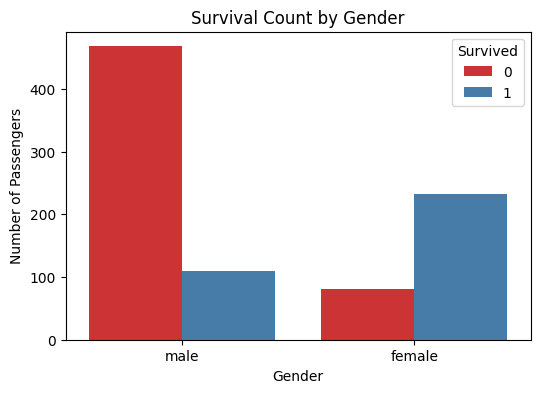

In [73]:
# Gender vs Survival
plt.figure(figsize=(6, 4))
sb.countplot(data=data, x='Sex', hue='Survived', palette='Set1')
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

*   Female passengers had a significantly higher survival rate than male passengers.
*   Most male passengers did not survive, whereas a larger proportion of female passengers survived.
*   This suggests that gender was an important factor influencing survival during the Titanic disaster.



**How does survival rate differ across passenger class (Pclass)?**

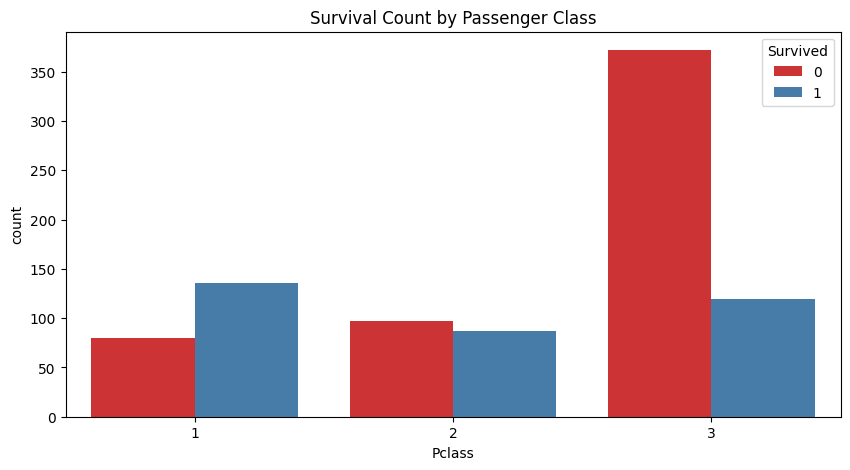

In [84]:
# How does survival rate differ across passenger class (Pclass)?
plt.figure(figsize=(10,5))
sb.countplot(data=data, x='Pclass', hue='Survived', palette='Set1')
plt.title('Survival Count by Passenger Class')
plt.show()

*   Passengers traveling in First Class (Pclass = 1) had the highest survival rate.
*   Third Class (Pclass = 3) passengers experienced the highest number of fatalities.
*   This indicates that passenger class had a strong influence on the likelihood of survival.




**What's the relationship between Age, Fare, Pclass, and Survival together?**

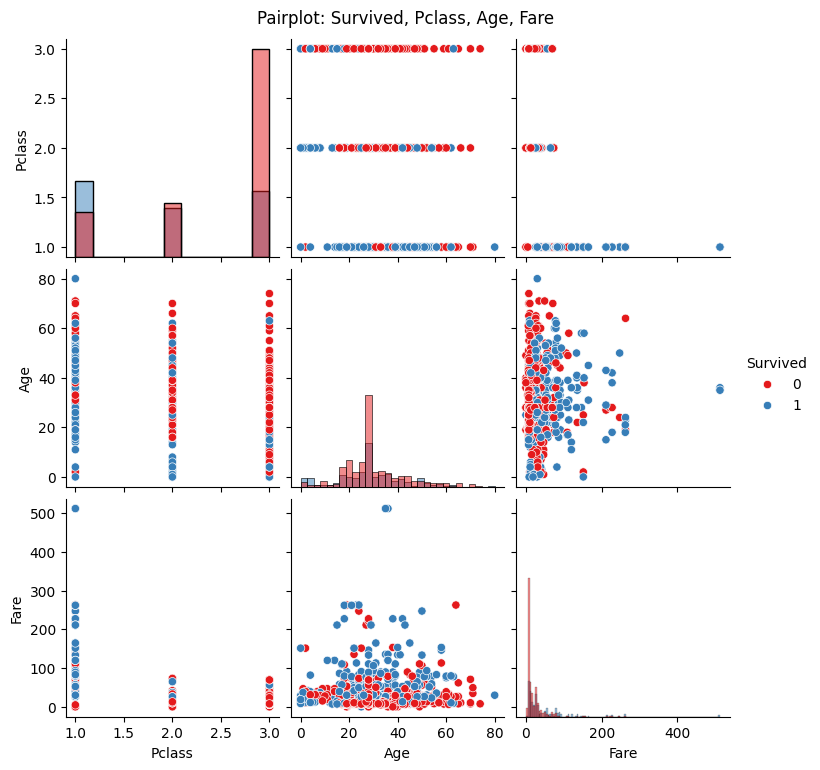

In [89]:
# What's the relationship between Age, Fare, Pclass, and Survival together?
sb.pairplot(data[['Survived', 'Pclass', 'Age', 'Fare']],
             hue='Survived', diag_kind='hist',
             palette='Set1')
plt.suptitle('Pairplot: Survived, Pclass, Age, Fare', y=1.02)
plt.show()

*   Ticket fare varies considerably across passenger classes, with first-class passengers generally paying higher fares.
*   No strong relationship is observed between Age and Fare.
*   Survivors are more concentrated among passengers with higher fares and in higher passenger classes.
*  The pairplot helps visualize relationships among multiple numerical features simultaneously.



**How correlated are the numeric features with each other and with survival?**

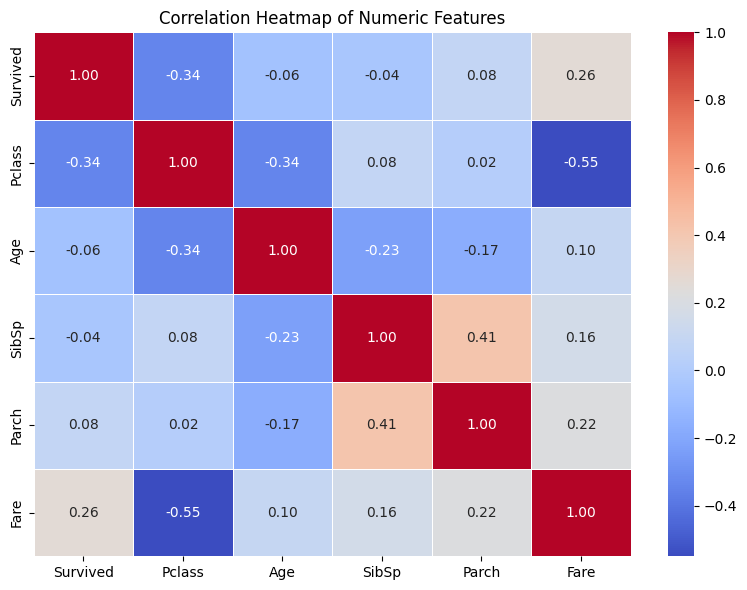

In [90]:
# How correlated are the numeric features with each other and with survival?
plt.figure(figsize=(8, 6))
corr = data[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
sb.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

*   Fare shows a positive correlation with Survived, suggesting that passengers who paid higher fares were more likely to survive.
*   Pclass has a negative correlation with Fare, indicating that higher-class passengers generally paid higher ticket prices.
*   Age has only a weak correlation with survival.
*   Overall, no extremely strong correlations exist among the numerical variables.

***How is Fare distributed, and does it differ by survival (boxplot) and vs Age?***


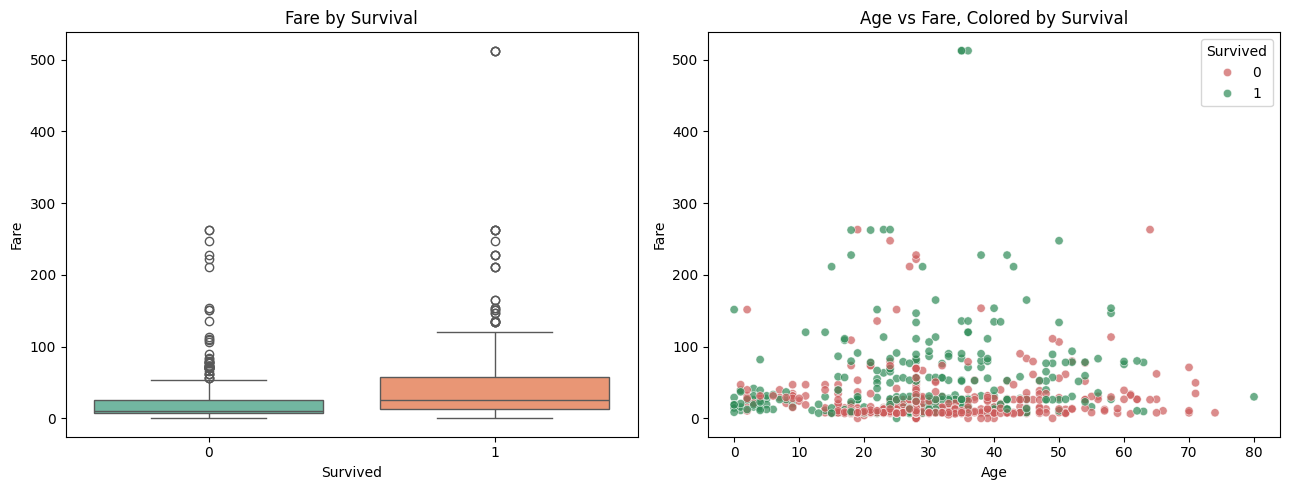

In [92]:
# How is Fare distributed, and does it differ by survival (boxplot) and vs Age
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot: Fare by Survived
sb.boxplot(x='Survived', y='Fare', data=data, hue='Survived', legend=False,
            ax=axes[0], palette='Set2')
axes[0].set_title('Fare by Survival')

# Scatterplot: Age vs Fare, colored by Survived
sb.scatterplot(x='Age', y='Fare', hue='Survived', data=data,
                 palette={0: 'indianred', 1: 'seagreen'}, alpha=0.7, ax=axes[1])
axes[1].set_title('Age vs Fare, Colored by Survival')

plt.tight_layout()
plt.show()

**Boxplot Observation**
*  Ticket fares are highly skewed and contain several high-value outliers.
Survivors generally paid higher fares than non-survivors.
*  This suggests that passengers with more expensive tickets had better survival chances.

**Scatter Plot Observation**
*  There is no strong linear relationship between Age and Fare.
Passengers of all ages paid a wide range of ticket fares.
*  A small number of passengers paid exceptionally high fares, which appear as outliers.

# **Overall Summary of Findings**
*   The Titanic dataset contains both numerical and categorical features useful for exploratory analysis.
*   Female passengers had a substantially higher survival rate than male passengers.
*   First-class passengers were more likely to survive than passengers in lower classes.
*   Ticket fare is positively associated with survival, while passenger class is negatively associated with fare.
*   Fare contains several outliers, whereas Age shows relatively fewer extreme values.
*   No strong linear relationship exists between Age and Fare, but the pairplot and heatmap reveal meaningful relationships between Fare, Pclass, and Survival